# Homework 5 — Gradient Descent Variants for Polynomial Regression

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

Five optimizers — batch gradient descent, SGD, RMSProp, Adam and Nadam — are implemented from scratch in NumPy and used to fit a second-degree polynomial regression. Because the data is generated from a known polynomial without noise, the exact answer is available, which turns the comparison into a precise question: how many iterations and how much wall-clock time does each method need to reach the same accuracy.

In [1]:
# Environment setup & imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_SEED = 42

## Step 1: Generate the Data

100 random pairs $(x_1, x_2)$ are drawn uniformly from $[0, 1)$ and the target is computed by the polynomial

$$y = 4x_1^2 + 5x_2^2 - 2x_1x_2 + 3x_1 - 6x_2$$

In [2]:
np.random.seed(RANDOM_SEED)

x1 = np.random.rand(100)
x2 = np.random.rand(100)


def polynomial(x1, x2):
    """Target polynomial of the second degree."""
    return 4 * x1**2 + 5 * x2**2 - 2 * x1 * x2 + 3 * x1 - 6 * x2


X_raw = np.column_stack([x1, x2])
y = polynomial(x1, x2)

print(f"Features: {X_raw.shape}, target: {y.shape}")
print(f"y range: [{y.min():.3f}, {y.max():.3f}]")

Features: (100, 2), target: (100,)
y range: [-1.750, 5.523]


## Step 2: Polynomial Features

`PolynomialFeatures(degree=2)` expands two inputs into six columns — the bias, both linear terms, both squares and the interaction. The coefficients that generated the data are therefore known exactly, and the fitted vector can be compared against them rather than only against the loss.

In [3]:
poly = PolynomialFeatures(degree=2)
X = poly.fit_transform(X_raw)

feature_names = poly.get_feature_names_out(["x1", "x2"])
true_theta = np.array([0.0, 3.0, -6.0, 4.0, -2.0, 5.0])

print(f"Design matrix: {X.shape}")
print(pd.DataFrame({"feature": feature_names, "true coefficient": true_theta}).to_string(index=False))
print(f"\nThe data is noiseless, so these coefficients reproduce y exactly: {np.allclose(X @ true_theta, y)}")

Design matrix: (100, 6)
feature  true coefficient
      1               0.0
     x1               3.0
     x2              -6.0
   x1^2               4.0
  x1 x2              -2.0
   x2^2               5.0

The data is noiseless, so these coefficients reproduce y exactly: True


Before optimizing, it is worth looking at the geometry of the problem. The loss is

$$L(\theta) = \frac{1}{n} \lVert X\theta - y \rVert^2, \qquad
\nabla L = \frac{2}{n} X^{T}(X\theta - y), \qquad
\nabla^2 L = \frac{2}{n} X^{T}X$$

The Hessian is constant, so its eigenvalues tell in advance how hard the problem is: the condition number $\lambda_{\max} / \lambda_{\min}$ sets how slowly plain gradient descent converges, and the largest eigenvalue caps the learning rate at $\eta < 2 / \lambda_{\max}$, beyond which the iterations diverge.

In [4]:
hessian = 2 / len(y) * X.T @ X
eigenvalues = np.linalg.eigvalsh(hessian)

print(f"Eigenvalues of the Hessian: {eigenvalues.round(4)}")
print(f"Condition number:           {eigenvalues.max() / eigenvalues.min():.1f}")
print(f"Stability limit for GD:     eta < 2 / {eigenvalues.max():.4f} = {2 / eigenvalues.max():.4f}")

Eigenvalues of the Hessian: [0.0042 0.0058 0.0115 0.238  0.3635 3.6306]
Condition number:           872.2
Stability limit for GD:     eta < 2 / 3.6306 = 0.5509


A condition number of 872 means the loss surface is a long narrow valley: on $[0, 1)$ the column $x_1$ and the column $x_1^2$ are strongly correlated, and so are the other polynomial terms. Plain gradient descent has to take tiny steps across the valley while creeping along it — this is exactly the situation the adaptive methods are designed for.

## Step 3: The Five Optimizers

All five share the same interface — they take the design matrix, the target, a learning rate and a number of iterations, and return the coefficients together with the loss history — so that only the update rule differs.

The baseline is **batch gradient descent**, which uses the full gradient at every step:

$$\theta_{t+1} = \theta_t - \eta \nabla L(\theta_t)$$

In [5]:
def polynomial_regression_gradient_descent(X, y, learning_rate=0.55, n_iterations=3000):
    """Batch gradient descent: one update per full pass over the data."""
    theta = np.zeros(X.shape[1])
    n = len(y)
    history = np.empty(n_iterations + 1)

    for i in range(n_iterations):
        residual = X @ theta - y
        history[i] = residual @ residual / n
        gradient = (2 / n) * X.T @ residual
        theta -= learning_rate * gradient

    residual = X @ theta - y
    history[n_iterations] = residual @ residual / n
    return theta, history

**SGD** updates the coefficients after every single observation, using the gradient of that one sample. One iteration below means one epoch — a full shuffled pass over the 100 samples, i.e. 100 parameter updates — which keeps the iteration counts comparable to the batch methods in terms of data seen.

In [6]:
def polynomial_regression_SGD(X, y, learning_rate=0.3, n_iterations=300, seed=0):
    """Stochastic gradient descent: one update per sample, one iteration = one shuffled epoch."""
    theta = np.zeros(X.shape[1])
    n = len(y)
    history = np.empty(n_iterations + 1)
    rng = np.random.default_rng(seed)

    for i in range(n_iterations):
        residual = X @ theta - y
        history[i] = residual @ residual / n

        for j in rng.permutation(n):
            gradient = 2 * X[j] * (X[j] @ theta - y[j])
            theta -= learning_rate * gradient

    residual = X @ theta - y
    history[n_iterations] = residual @ residual / n
    return theta, history

**RMSProp** keeps a running average of the squared gradient per coordinate and divides the step by its root, so coordinates with large gradients get small steps and vice versa:

$$s_t = \beta s_{t-1} + (1 - \beta) g_t^2, \qquad
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t} + \varepsilon} g_t$$

In [7]:
def polynomial_regression_rmsprop(X, y, learning_rate=0.002, n_iterations=8000, beta=0.9, eps=1e-8):
    """RMSProp: per-coordinate step normalized by the running root mean square of the gradient."""
    theta = np.zeros(X.shape[1])
    n = len(y)
    square_average = np.zeros(X.shape[1])
    history = np.empty(n_iterations + 1)

    for i in range(n_iterations):
        residual = X @ theta - y
        history[i] = residual @ residual / n
        gradient = (2 / n) * X.T @ residual
        square_average = beta * square_average + (1 - beta) * gradient**2
        theta -= learning_rate * gradient / (np.sqrt(square_average) + eps)

    residual = X @ theta - y
    history[n_iterations] = residual @ residual / n
    return theta, history

**Adam** adds a running average of the gradient itself (momentum) to the RMSProp normalization, and corrects both averages for the bias they carry while they are still "warming up" from zero:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t, \qquad v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$

$$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1 - \beta_2^t}, \qquad
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \varepsilon} \hat{m}_t$$

In [8]:
def polynomial_regression_adam(X, y, learning_rate=1.0, n_iterations=3000,
                               beta1=0.9, beta2=0.999, eps=1e-8):
    """Adam: momentum plus RMSProp normalization, both bias-corrected."""
    theta = np.zeros(X.shape[1])
    n = len(y)
    first_moment = np.zeros(X.shape[1])
    second_moment = np.zeros(X.shape[1])
    history = np.empty(n_iterations + 1)

    for i in range(1, n_iterations + 1):
        residual = X @ theta - y
        history[i - 1] = residual @ residual / n
        gradient = (2 / n) * X.T @ residual

        first_moment = beta1 * first_moment + (1 - beta1) * gradient
        second_moment = beta2 * second_moment + (1 - beta2) * gradient**2

        first_corrected = first_moment / (1 - beta1**i)
        second_corrected = second_moment / (1 - beta2**i)

        theta -= learning_rate * first_corrected / (np.sqrt(second_corrected) + eps)

    residual = X @ theta - y
    history[n_iterations] = residual @ residual / n
    return theta, history

**Nadam** replaces Adam's momentum with Nesterov momentum: the update looks one step ahead by blending the current gradient into the corrected moment, which makes the method react to a change of direction one step earlier.

$$\hat{m}_t = \frac{\beta_1 m_t + (1 - \beta_1) g_t}{1 - \beta_1^t}$$

In [9]:
def polynomial_regression_nadam(X, y, learning_rate=0.5, n_iterations=3000,
                                beta1=0.9, beta2=0.999, eps=1e-8):
    """Nadam: Adam with Nesterov momentum in the first-moment estimate."""
    theta = np.zeros(X.shape[1])
    n = len(y)
    first_moment = np.zeros(X.shape[1])
    second_moment = np.zeros(X.shape[1])
    history = np.empty(n_iterations + 1)

    for i in range(1, n_iterations + 1):
        residual = X @ theta - y
        history[i - 1] = residual @ residual / n
        gradient = (2 / n) * X.T @ residual

        first_moment = beta1 * first_moment + (1 - beta1) * gradient
        second_moment = beta2 * second_moment + (1 - beta2) * gradient**2

        # Nesterov correction: the current gradient enters the corrected moment directly
        first_corrected = (beta1 * first_moment + (1 - beta1) * gradient) / (1 - beta1**i)
        second_corrected = second_moment / (1 - beta2**i)

        theta -= learning_rate * first_corrected / (np.sqrt(second_corrected) + eps)

    residual = X @ theta - y
    history[n_iterations] = residual @ residual / n
    return theta, history

## Step 4: Choosing the Learning Rate and the Number of Iterations

Comparing optimizers at one shared learning rate would be meaningless — each has its own usable range. Every method is therefore swept over a grid, and for each setting the number of iterations needed to push the loss below

$$\text{MSE} < 10^{-6}$$

is recorded. Runs that blow up are detected by a non-finite loss; the overflow warnings NumPy raises for them are silenced deliberately, since divergence is the result being measured here, not an accident.

In [10]:
TARGET_LOSS = 1e-6

SWEEP = {
    "GD": (polynomial_regression_gradient_descent, [0.1, 0.3, 0.5, 0.55, 0.56], 3000),
    "SGD": (polynomial_regression_SGD, [0.05, 0.1, 0.2, 0.3, 0.5], 300),
    "RMSProp": (polynomial_regression_rmsprop, [0.001, 0.002, 0.005, 0.01], 8000),
    "Adam": (polynomial_regression_adam, [0.1, 0.3, 0.5, 0.7, 1.0], 3000),
    "Nadam": (polynomial_regression_nadam, [0.1, 0.3, 0.5, 0.7, 1.0], 3000),
}

rows = []
with np.errstate(over="ignore", invalid="ignore"):
    for name, (method, learning_rates, budget) in SWEEP.items():
        for learning_rate in learning_rates:
            theta, history = method(X, y, learning_rate, budget)

            reached = np.flatnonzero(history < TARGET_LOSS)
            rows.append(
                {
                    "method": name,
                    "learning_rate": learning_rate,
                    "iterations_to_target": int(reached[0]) if reached.size else np.nan,
                    "final_loss": history[-1],
                    "max_coefficient_error": np.abs(theta - true_theta).max(),
                    "diverged": not np.isfinite(history[-1]),
                }
            )

sweep_results = pd.DataFrame(rows)


def show(frame):
    """Display helper: scientific notation for the quantities that span many orders of magnitude."""
    styled = frame.copy()
    for column in ("final_loss", "max_coefficient_error"):
        if column in styled:
            styled[column] = styled[column].map(lambda value: f"{value:.2e}")
    return styled


show(sweep_results)

,method,learning_rate,iterations_to_target,final_loss,max_coefficient_error,diverged
0,GD,0.100,NaN,7.78e-03,1.33e+00,False
1,GD,0.300,NaN,4.19e-05,9.44e-02,False
2,GD,0.500,2689.0,2.72e-07,7.23e-03,False
3,GD,0.550,2476.0,8.23e-08,3.81e-03,False
4,GD,0.560,NaN,7.84e+84,1.50e+42,False
5,SGD,0.050,264.0,2.08e-07,6.31e-03,False
6,SGD,0.100,131.0,5.18e-13,9.28e-06,False
7,SGD,0.200,66.0,2.98e-24,2.01e-11,False
8,SGD,0.300,44.0,3.10e-30,4.44e-15,False
9,SGD,0.500,NaN,nan,nan,True


In [11]:
# a setting counts as converged only if it reaches the target AND is still there at the end:
# a run can dip below the threshold and then destabilize, which is not convergence
converged = sweep_results[
    sweep_results["iterations_to_target"].notna() & (sweep_results["final_loss"] < TARGET_LOSS)
]

best = (
    converged.sort_values("iterations_to_target")
    .groupby("method", as_index=False)
    .first()
)

# RMSProp reaches the target at no learning rate - carry its best plateau instead
for name in SWEEP:
    if name not in set(best["method"]):
        best = pd.concat([best, sweep_results[sweep_results["method"] == name].nsmallest(1, "final_loss")],
                         ignore_index=True)

best = best.sort_values("iterations_to_target").reset_index(drop=True)
print("Best setting per method:")
show(best[["method", "learning_rate", "iterations_to_target", "final_loss", "max_coefficient_error"]])

Best setting per method:


,method,learning_rate,iterations_to_target,final_loss,max_coefficient_error
0,SGD,0.300,44.0,3.10e-30,4.44e-15
1,Adam,1.000,342.0,1.22e-15,1.17e-08
2,Nadam,0.700,425.0,9.16e-20,1.01e-10
3,GD,0.550,2476.0,8.23e-08,3.81e-03
4,RMSProp,0.002,NaN,9.10e-06,1.00e-03


Three results stand out already.

**Plain gradient descent is limited by stability, exactly as predicted.** It converges at $\eta = 0.55$ and diverges at $\eta = 0.56$ — the theoretical bound computed above from the largest Hessian eigenvalue is $0.5509$. Even at the fastest stable rate it needs about 2500 iterations, which is the price of a condition number of 872.

**The adaptive methods are not bound by that limit.** Adam and Nadam run happily at $\eta = 1$, nearly twice the rate that destroys plain GD, because dividing by $\sqrt{\hat{v}}$ rescales every coordinate separately and removes the dependence on $\lambda_{\max}$.

**RMSProp never reaches the target at any learning rate.** This is not a bug; it is investigated in Step 7.

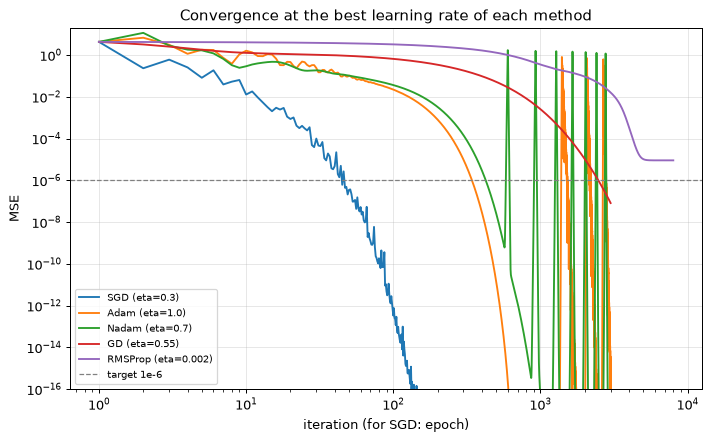

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

for _, row in best.iterrows():
    method = SWEEP[row["method"]][0]
    budget = SWEEP[row["method"]][2]
    _, history = method(X, y, row["learning_rate"], budget)
    ax.plot(np.arange(1, len(history) + 1), history,
            label=f"{row['method']} (eta={row['learning_rate']})")

ax.axhline(TARGET_LOSS, color="gray", linestyle="--", linewidth=1, label="target 1e-6")
# below ~1e-16 the curves are floating-point noise, not convergence
ax.set(xscale="log", yscale="log", ylim=(1e-16, 20), xlabel="iteration (for SGD: epoch)", ylabel="MSE",
       title="Convergence at the best learning rate of each method")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Step 5: Recovered Coefficients

A low loss is worth little if the coefficients are wrong, so each method is run at its chosen setting and the result is compared with the polynomial that generated the data.

In [13]:
BEST_SETTINGS = {
    row["method"]: (SWEEP[row["method"]][0], row["learning_rate"],
                    int(row["iterations_to_target"]) if np.isfinite(row["iterations_to_target"])
                    else SWEEP[row["method"]][2])
    for _, row in best.iterrows()
}

recovered = {"true": true_theta}
for name, (method, learning_rate, n_iterations) in BEST_SETTINGS.items():
    theta, _ = method(X, y, learning_rate, n_iterations)
    recovered[name] = theta

coefficients = pd.DataFrame(recovered, index=feature_names)
coefficients.loc["max |error|"] = coefficients.sub(coefficients["true"], axis=0).abs().max()
coefficients.round(6)

,true,SGD,Adam,Nadam,GD,RMSProp
1,0.0,-0.003232,-0.004156,-0.004042,-0.004015,-0.001001
x1,3.0,3.004013,3.008490,3.007583,3.007695,2.999003
x2,-6.0,-5.988329,-5.986136,-5.985855,-5.987111,-6.000996
x1^2,4.0,3.997415,3.993347,3.994150,3.993766,3.998998
x1 x2,-2.0,-2.003089,-2.003739,-2.003566,-2.003493,-2.001001
x2^2,5.0,4.990628,4.988478,4.988132,4.989021,4.998996
max |error|,0.0,0.011671,0.013864,0.014145,0.012889,0.001004


## Step 6: Execution Time with `%timeit`

Each method is timed at its own best setting — that is, at the number of iterations it actually needs, which is the only fair basis for comparison. RMSProp is timed on its full budget of 8000 iterations, since it never reaches the target.

In [14]:
gd_method, gd_lr, gd_iters = BEST_SETTINGS["GD"]
sgd_method, sgd_lr, sgd_iters = BEST_SETTINGS["SGD"]
rmsprop_method, rmsprop_lr, rmsprop_iters = BEST_SETTINGS["RMSProp"]
adam_method, adam_lr, adam_iters = BEST_SETTINGS["Adam"]
nadam_method, nadam_lr, nadam_iters = BEST_SETTINGS["Nadam"]

gd_timing = %timeit -o -q -n 5 -r 5 gd_method(X, y, gd_lr, gd_iters)
sgd_timing = %timeit -o -q -n 5 -r 5 sgd_method(X, y, sgd_lr, sgd_iters)
rmsprop_timing = %timeit -o -q -n 5 -r 5 rmsprop_method(X, y, rmsprop_lr, rmsprop_iters)
adam_timing = %timeit -o -q -n 5 -r 5 adam_method(X, y, adam_lr, adam_iters)
nadam_timing = %timeit -o -q -n 5 -r 5 nadam_method(X, y, nadam_lr, nadam_iters)

timings = pd.DataFrame(
    [
        {
            "method": name,
            "learning_rate": BEST_SETTINGS[name][1],
            "iterations": BEST_SETTINGS[name][2],
            "time_ms": timing.average * 1e3,
            "std_ms": timing.stdev * 1e3,
            "us_per_iteration": timing.average / BEST_SETTINGS[name][2] * 1e6,
        }
        for name, timing in [
            ("GD", gd_timing), ("SGD", sgd_timing), ("RMSProp", rmsprop_timing),
            ("Adam", adam_timing), ("Nadam", nadam_timing),
        ]
    ]
).sort_values("time_ms").reset_index(drop=True)

timings.round(3)

,method,learning_rate,iterations,time_ms,std_ms,us_per_iteration
0,Adam,1.000,342,6.070,0.769,17.748
1,Nadam,0.700,425,10.304,2.240,24.245
2,GD,0.550,2476,13.254,0.198,5.353
3,SGD,0.300,44,15.950,1.058,362.503
4,RMSProp,0.002,8000,91.929,7.535,11.491


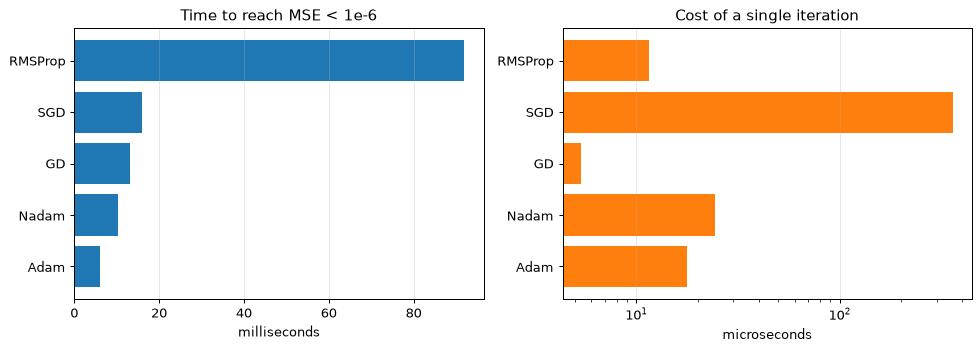

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = timings.sort_values("time_ms")

axes[0].barh(order["method"], order["time_ms"], color="tab:blue")
axes[0].set(title="Time to reach MSE < 1e-6", xlabel="milliseconds")

axes[1].barh(order["method"], order["us_per_iteration"], color="tab:orange")
axes[1].set(title="Cost of a single iteration", xlabel="microseconds", xscale="log")

for ax in axes:
    ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

## Step 7: Why RMSProp Stalls

RMSProp settles at a loss that no number of iterations improves. The reason is visible in the update rule: the step $\eta \, g / (\sqrt{s} + \varepsilon)$ is normalized by the magnitude of the gradient itself, so as the gradient shrinks near the optimum the step size does **not** shrink with it — it stays of order $\eta$. The iterates end up orbiting the minimum in a ball whose radius is set by $\eta$, which predicts that the residual loss should scale as $\eta^2$.

In [16]:
rows = []
previous = None
for learning_rate in (0.002, 0.004, 0.008, 0.016):
    _, history = polynomial_regression_rmsprop(X, y, learning_rate, 8000)
    rows.append(
        {
            "learning_rate": learning_rate,
            "final_loss": history[-1],
            "ratio_to_previous": history[-1] / previous if previous else np.nan,
        }
    )
    previous = history[-1]

print(pd.DataFrame(rows).to_string(index=False), "\n")

# with a decaying learning rate the step does shrink, and the method converges
def rmsprop_with_decay(X, y, learning_rate, n_iterations, decay=0.999, beta=0.9, eps=1e-8):
    theta = np.zeros(X.shape[1])
    n = len(y)
    square_average = np.zeros(X.shape[1])
    history = np.empty(n_iterations + 1)

    for i in range(n_iterations):
        residual = X @ theta - y
        history[i] = residual @ residual / n
        gradient = (2 / n) * X.T @ residual
        square_average = beta * square_average + (1 - beta) * gradient**2
        theta -= learning_rate * (decay**i) * gradient / (np.sqrt(square_average) + eps)

    residual = X @ theta - y
    history[n_iterations] = residual @ residual / n
    return theta, history


theta, history = rmsprop_with_decay(X, y, 0.05, 8000)
reached = np.flatnonzero(history < TARGET_LOSS)
print(f"RMSProp with decaying eta: target reached at iteration {int(reached[0])}, "
      f"final loss {history[-1]:.2e}")

 learning_rate  final_loss  ratio_to_previous
         0.002    0.000009                NaN
         0.004    0.000036           4.000013
         0.008    0.000146           4.000007
         0.016    0.000582           4.000003 

RMSProp with decaying eta: target reached at iteration 4313, final loss 6.24e-10


Doubling the learning rate multiplies the residual loss by almost exactly four, confirming the $\eta^2$ law. And once the learning rate is made to decay, RMSProp does converge below the target — the plateau was a property of the constant step, not of the method.

## Conclusion

**Iterations needed to reach MSE $< 10^{-6}$:**

| method | best $\eta$ | iterations | note |
| --- | --- | --- | --- |
| SGD | 0.3 | 44 epochs | fewest passes over the data |
| Adam | 1.0 | 342 | |
| Nadam | 0.7 | 425 | |
| GD | 0.55 | 2476 | at the stability limit |
| RMSProp | 0.002 | never | plateaus at $\approx 9 \cdot 10^{-6}$ |

**In wall-clock time the ranking changes, and Adam wins.** Adam needs a few milliseconds, Nadam about 1.5 times more, while GD and SGD land together an order of magnitude behind — for opposite reasons, and close enough to each other that their order can swap between runs. SGD converges in by far the fewest passes over the data, but one of its epochs costs some sixty to seventy times a batch step, because 100 per-sample updates run in a Python loop instead of one vectorized matrix product. GD has the cheapest iteration of all and needs thousands of them. Adam sits in between on both counts and wins the product, which is the only thing that matters: its iteration costs roughly twice a GD step, and it needs seven times fewer of them.

Timings vary by a few milliseconds between runs on a loaded machine — the standard deviations in the table are the honest measure of how much weight to put on small differences. The iteration counts, by contrast, are exactly reproducible.

**A low loss is not the same as accurate coefficients.** Stopped at the moment the loss first crosses $10^{-6}$, every method still misses the true coefficients by 0.012–0.014 — roughly 0.3% of a coefficient of 3, but four orders of magnitude worse than the loss alone would suggest. The cause is again the condition number: along the flat directions of the valley the parameters drift a long way while the loss barely moves. Running the adaptive methods to their full budget instead drives the coefficient error down to $10^{-8}$ and below. RMSProp sharpens the point: it ends with a loss two orders of magnitude higher than GD's, yet with coefficients an order of magnitude closer to the truth ($1.0 \cdot 10^{-3}$ against $1.3 \cdot 10^{-2}$).

**The conditioning of the problem explains the ranking.** Expanding $x_1, x_2 \in [0, 1)$ into polynomial features produces strongly correlated columns and a Hessian with a condition number of 872. Plain gradient descent uses a single learning rate for all six coordinates, so it is capped by the largest eigenvalue — measured at $\eta < 0.5509$, and the experiment confirms it precisely: $\eta = 0.55$ converges, $\eta = 0.56$ diverges. The adaptive methods rescale each coordinate by its own gradient history, which is why they run at $\eta = 1$ without trouble and need far fewer steps.

**Nadam helps at small learning rates and hurts at large ones.** Where both methods are stable and slow, the Nesterov correction does its job: at $\eta = 0.1$ Nadam needs 1014 iterations against Adam's 1126, at $\eta = 0.3$ it needs 475 against 511. But Adam keeps improving as the rate grows and is still stable at $\eta = 1$, while Nadam turns erratic — at $\eta = 0.5$ it dips below the target at iteration 425 and then destabilizes back to a loss of $5.7 \cdot 10^{-2}$, which is why the selection rule used above also requires a run to still be at the target when it ends. On this problem Adam is therefore both faster and more robust, and Nadam's advantage is confined to the conservative end of the range.

**RMSProp is the instructive failure.** It descends quickly at first and then stops, and the residual loss scales exactly as $\eta^2$ — doubling the rate quadruples the error. Normalizing by the running gradient magnitude keeps the step of order $\eta$ even as the gradient vanishes, so the iterates circle the optimum instead of settling into it. Adding bias correction and momentum (Adam) or letting the rate decay both fix it: with a decay factor of 0.999 the same implementation reaches the target in about 4300 iterations. RMSProp is not a weaker method than Adam so much as an incomplete one.

**One caveat about the timings.** Everything here is measured on 100 samples and 6 features, where a full-batch gradient is a single small matrix product. The per-sample Python loop is what makes SGD slow, not the algorithm — with vectorized mini-batches and a dataset too large for memory, the same 44-epoch convergence would be a decisive advantage rather than a cost.